In [1]:
import pandas as pd
df = pd.read_csv('http://114.207.245.181:13000/csv/fish01.csv')
df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
# 1. 컬럼변경,
# 2. 타입변경, <= 보류
# 3. 특성, 타겟 x,y
# 4. 데이터분할 8:2
# 5. 스케일러 StandardScaler

In [2]:
df.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [4]:
t1 = {'Species':'종류', 'Weight':'무게', 'Length':'길이', 'Diagonal':'대각선', 'Height':'높이', 'Width':'넓이'}
df.rename(columns=t1, inplace=True)

In [5]:
df.dtypes

종류      object
무게     float64
길이     float64
대각선    float64
높이     float64
넓이     float64
dtype: object

In [6]:
x = df[df.columns[1:]].values
y = df['종류'].values
x.shape, y.shape

((159, 5), (159,))

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((127, 5), (32, 5), (127,), (32,))

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# log_loss 는 로지스틱 회귀 손실함수
from sklearn.linear_model import SGDClassifier

# loss는 실제값 - 오차값을 비교, 학습횟수 100번
model = SGDClassifier(loss="log_loss", max_iter=100, random_state=123)
model.fit(x_train_scaled, y_train)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
# 한 번 훈련한 결과
model.score(x_train_scaled, y_train), model.score(x_test_scaled, y_test)

(0.8582677165354331, 0.90625)

In [113]:
# 누적 훈련
model.partial_fit(x_train_scaled, y_train)
model.score(x_train_scaled, y_train), model.score(x_test_scaled, y_test)

(0.9291338582677166, 0.96875)

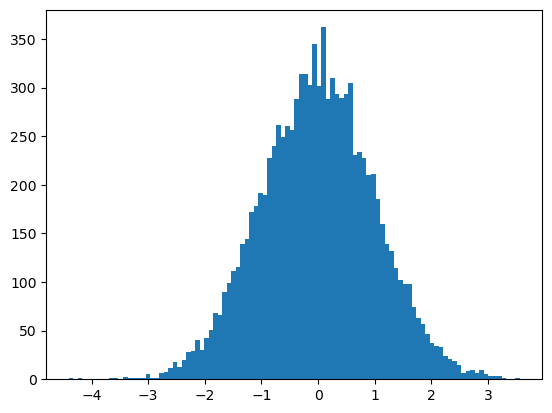

In [ ]:
# 정규분포
import tensorflow as tf
import matplotlib.pyplot as plt

# 랜덤하게 10000개의 숫자를 생성시킴
random_normal = tf.random.normal([10000], mean=0, stddev=1)

plt.hist(random_normal, bins=100)
plt.show()


In [ ]:
# x의 값은 1이고 결과값은 0이 되는 모델 학습
x = 1 #특성
y = 0 #정답

# 가중치 : x에 곱해지는 값
w = tf.random.normal([1], mean=0, stddev=1)

# bias : x에 더해지는 값
b = tf.random.normal([1], mean=0, stddev=1)
x, y, w, b

(1,
 0,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.7501922], dtype=float32)>,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.03067437], dtype=float32)>)

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 (이진 분류)        # 소프트맥스 (다중 분류)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [112]:
# 학습횟수 1000 에포크 (epoch)
for i in range(1000):
    output = sigmoid(x * w + (1 + b))
    error = y - output

    w = w + (x * 0.1 * error)
    b = b + (1 * 0.1 * error)
    print(i, output, error)

0 [0.9416331] [-0.9416331]
1 [0.9303799] [-0.9303799]
2 [0.9173189] [-0.9173189]
3 [0.902296] [-0.902296]
4 [0.88519174] [-0.88519174]
5 [0.865937] [-0.865937]
6 [0.8445283] [-0.8445283]
7 [0.82104] [-0.82104]
8 [0.79562986] [-0.79562986]
9 [0.7685382] [-0.7685382]
10 [0.74007684] [-0.74007684]
11 [0.7106108] [-0.7106108]
12 [0.6805347] [-0.6805347]
13 [0.6502466] [-0.6502466]
14 [0.62012386] [-0.62012386]
15 [0.59050405] [-0.59050405]
16 [0.5616715] [-0.5616715]
17 [0.5338517] [-0.5338517]
18 [0.5072105] [-0.5072105]
19 [0.48185843] [-0.48185843]
20 [0.45785776] [-0.45785776]
21 [0.43523058] [-0.43523058]
22 [0.41396752] [-0.41396752]
23 [0.39403534] [-0.39403534]
24 [0.37538382] [-0.37538382]
25 [0.35795182] [-0.35795182]
26 [0.34167126] [-0.34167126]
27 [0.32647106] [-0.32647106]
28 [0.31227946] [-0.31227946]
29 [0.2990261] [-0.2990261]
30 [0.28664288] [-0.28664288]
31 [0.2750652] [-0.2750652]
32 [0.2642322] [-0.2642322]
33 [0.25408688] [-0.25408688]
34 [0.2445765] [-0.2445765]
35 [

In [140]:
import numpy as np

x = np.array([
    [1,1],
    [1,0],
    [0,1],
    [0,0]
])

# y = np.array([[1],[0],[0],[0]])
# y = np.array([[1],[1],[1],[0]])
y = np.array([[0],[1],[1],[0]])

w = tf.random.normal([2], mean=0, stddev=1)
b = tf.random.normal([1], mean=0, stddev=1)

# 특성이 (n, 2) => (n, 1)
x.shape, y.shape

((4, 2), (4, 1))

In [141]:
x, y, w, b

(array([[1, 1],
        [1, 0],
        [0, 1],
        [0, 0]]),
 array([[0],
        [1],
        [1],
        [0]]),
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([-1.5521264,  0.664262 ], dtype=float32)>,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-0.8842686], dtype=float32)>)

In [142]:
# 2000번 에포크 훈련 후에 w1, w2, b를 구했음
for i in range(2000):

    # 4개의 데이터를 가져오기
    for j in range(4):

        #output = x1 * w1 + x2 * w2 + b
        output  = sigmoid( (x[j][0] * w[0] + x[j][1] * w[1]) + (1 * b))
        error   = y[j][0] - output
        w       = w + x[j] * 0.1 * error
        b       = b + 1 * 0.1 * error

    if i % 100 == 99:
        print(i, error, output)

99 [-0.50989658] [0.5098966]
199 [-0.51223141] [0.5122314]
299 [-0.51269948] [0.5126995]
399 [-0.51279378] [0.5127938]
499 [-0.51281285] [0.51281285]
599 [-0.51281667] [0.51281667]
699 [-0.51281744] [0.51281744]
799 [-0.51281756] [0.51281756]
899 [-0.51281762] [0.5128176]
999 [-0.51281762] [0.5128176]
1099 [-0.51281762] [0.5128176]
1199 [-0.51281762] [0.5128176]
1299 [-0.51281762] [0.5128176]
1399 [-0.51281762] [0.5128176]
1499 [-0.51281762] [0.5128176]
1599 [-0.51281762] [0.5128176]
1699 [-0.51281762] [0.5128176]
1799 [-0.51281762] [0.5128176]
1899 [-0.51281762] [0.5128176]
1999 [-0.51281762] [0.5128176]


In [143]:
# 예측하기
for i in range(4):
    output = sigmoid( (x[i][0] * w[0] + x[i][1] * w[1]) + (1 * b))
    print(x[i], y[i], output)

[1 1] [0] [0.5128176]
[1 0] [1] [0.5128176]
[0 1] [1] [0.5]
[0 0] [0] [0.5]
